# Iris Flower Classification

## Problem Statement
The goal of this project is to classify iris flowers into three species:
- Setosa
- Versicolor
- Virginica

based on their physical measurements:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

## Objective
Build a classification model and extract meaningful insights from the dataset.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [36]:
df = pd.read_csv("/kaggle/input/datasets/komalharshita/iris-dataset/IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [37]:
print("Shape of dataset: ", df.shape)
print("\nColumns: ", df.columns)
print("\nData info: ")
df.info()

Shape of dataset:  (150, 5)

Columns:  Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Data info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [38]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [39]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

> no missing values -- clean dataset

# Target distribution

In [40]:
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### Observation:
The dataset is balanced, with equal samples for each species.

# Pairplot

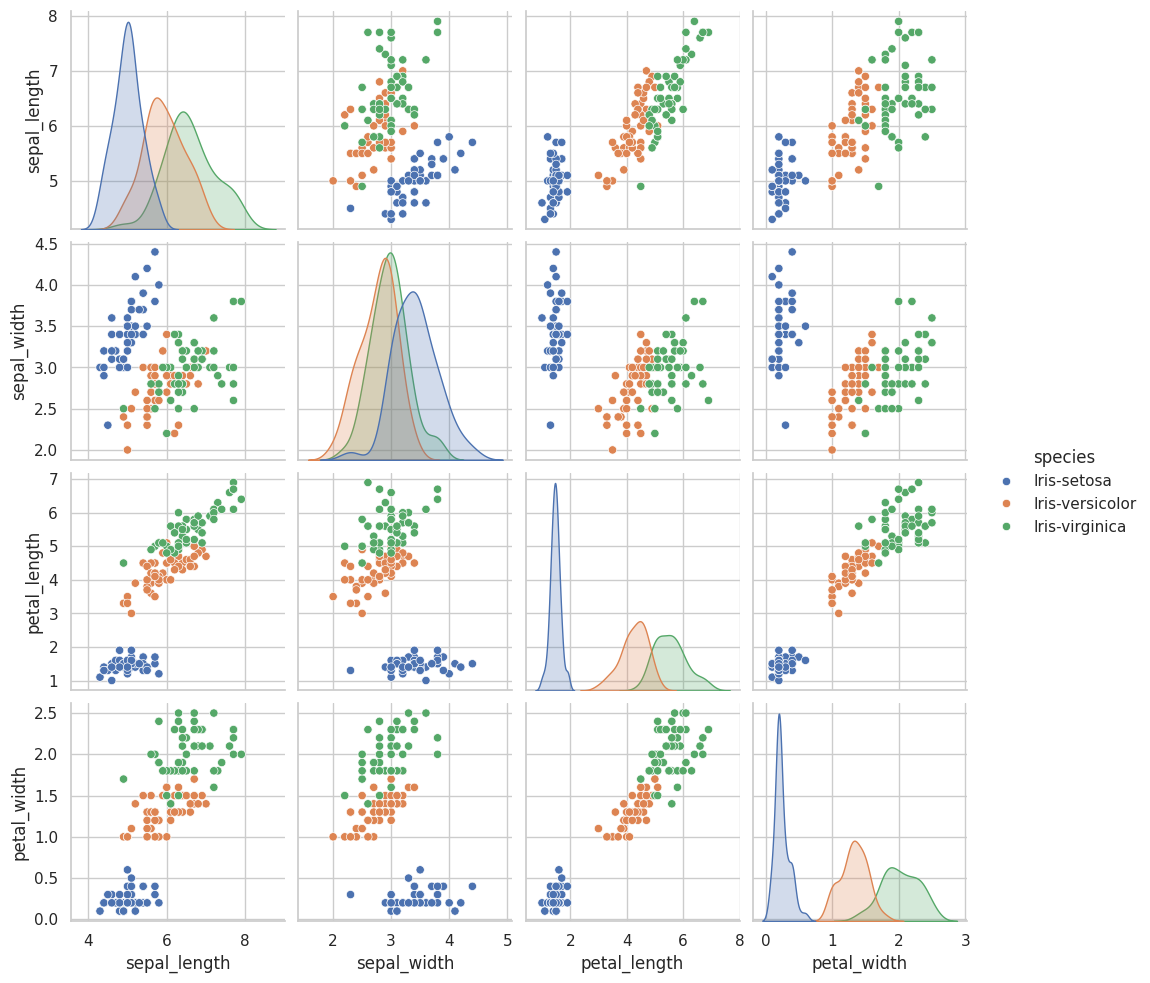

In [41]:
sns.pairplot(df, hue = "species")
plt.show()

### Insight:
- Petal length and petal width clearly separate the species.
- Setosa is completely distinct from the other two species.
- Versicolor and Virginica show some overlap.

# Correlation heatmap

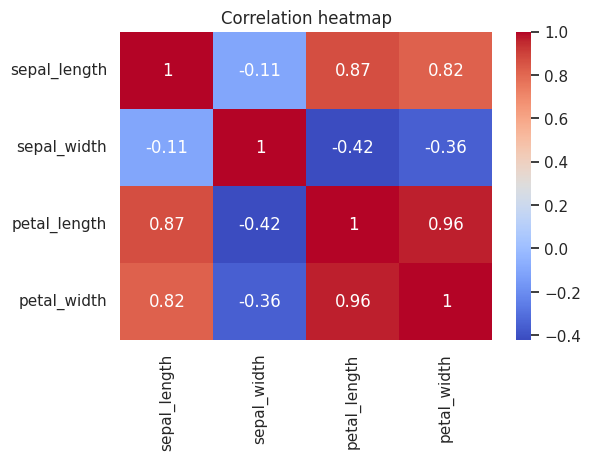

In [42]:
plt.figure(figsize = (6,4))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "coolwarm")
plt.title("Correlation heatmap")
plt.show()

### Insight:
- Petal features have strong correlation with each other.
- Sepal features are less strongly correlated with target behavior.

# Boxplots 
## Distribution analysis

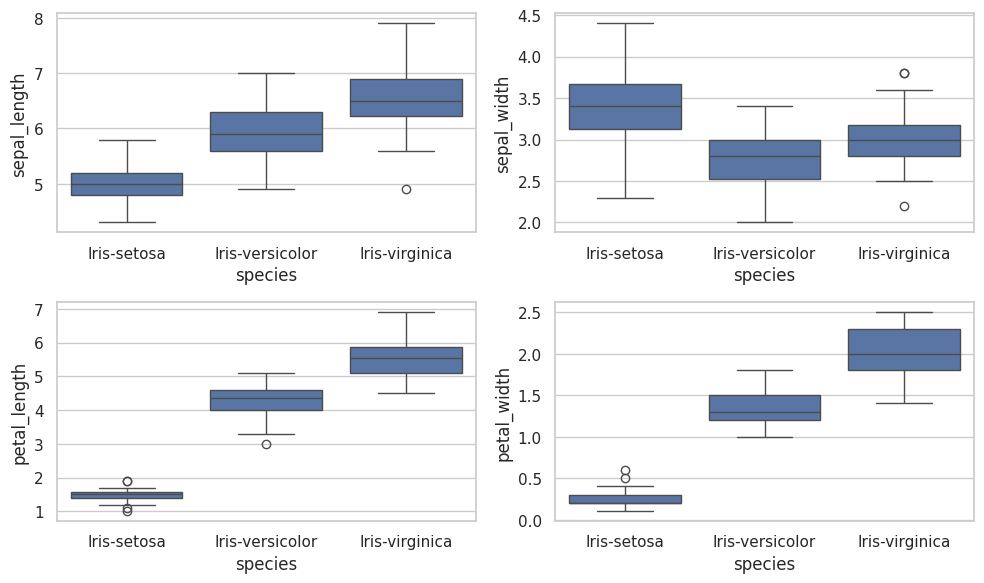

In [43]:
plt.figure(figsize=(10,6))

for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(x='species', y=col, data=df)

plt.tight_layout()
plt.show()

### Insight:
- Setosa has very distinct petal size distribution.
- Versicolor and Virginica distributions overlap slightly.

# Data preprocessing

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop("species", axis=1)
y = df["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model

In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# K-nearest neighbours (KNN) model

In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [48]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Model comparison

In [49]:
print("Model Comparison:")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

Model Comparison:
Logistic Regression Accuracy: 1.0
KNN Accuracy: 1.0


## Model Comparison

- Logistic Regression and KNN both achieved high accuracy.
- Logistic Regression is preferred due to:
  - Simplicity
  - Interpretability
  - Faster computation

- KNN is effective but depends on distance calculations and scaling.

### Conclusion:
For this dataset, Logistic Regression is sufficient and efficient.

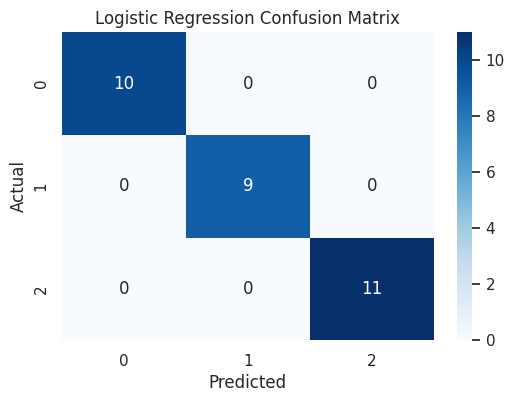

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Evaluation Insights

- Both Logistic Regression and KNN achieve high accuracy on the dataset.
- Setosa is classified perfectly due to its distinct feature distribution.
- Misclassifications, if any, occur between Versicolor and Virginica.
- This indicates that these two classes have overlapping feature characteristics.

## Interpretation

- Petal length and petal width play a major role in classification.
- The dataset is well-structured and linearly separable for certain classes.
- Logistic Regression performs well due to clear decision boundaries.
- KNN performs well due to local similarity between samples.

# Feature importance 

In [51]:
coef_df = pd.DataFrame(log_model.coef_, columns=X.columns, index=log_model.classes_)

coef_df

,sepal_length,sepal_width,petal_length,petal_width
Iris-setosa,-1.005525,1.140730,-1.811450,-1.704576
Iris-versicolor,0.530013,-0.283113,-0.344019,-0.711463
Iris-virginica,0.475512,-0.857617,2.155469,2.416038


## Feature Importance Analysis

- Petal length and petal width have the highest influence on classification.
- Sepal features contribute less compared to petal features.
- Each class has a different coefficient pattern, indicating how features influence classification.

### Key Insight:
Petal measurements are the most critical features for distinguishing between iris species.

# Final Conclusion

- The Iris dataset is clean, balanced, and suitable for classification tasks.
- Petal features are the most important predictors of species.
- Logistic Regression and KNN both perform well, with high accuracy.
- The model successfully distinguishes Setosa, while slight overlap exists between Versicolor and Virginica.

### Overall:
This project demonstrates a complete machine learning workflow from data analysis to model evaluation and interpretation.